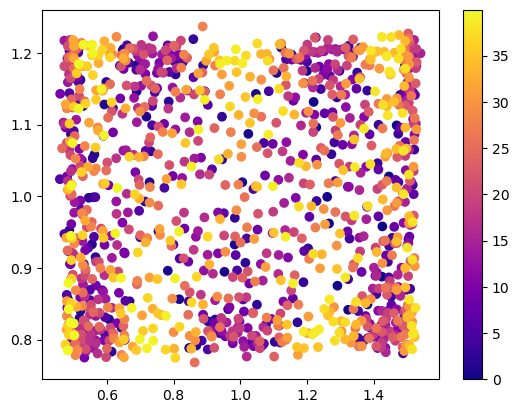

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# =====================================================================
# 1. USER CONFIGURATION (SET YOUR INITIAL CONDITIONS & CONSTANTS)
# =====================================================================
X0, Y0 = 1.5, 1.2         # Initial positions
VX0, VY0 = -0.2, 0.4      # Initial velocities
K1_TRUE, K2_TRUE = 100, np.e # True spring constants
L1, L2 = 1.0, 1.0         # Spring rest lengths
T_MAX, DT = 40.0, 1/30    # Simulation time parameters

t_eval = np.arange(0, T_MAX, DT)
true_params = [X0, Y0, VX0, VY0, K1_TRUE, K2_TRUE]

# =====================================================================
# 2. SLIDING 90-DEGREE COUPLED ACCELERATION LOGIC
# =====================================================================
def get_sliding_accelerations(x, y, k1, k2):
    # Avoid division by zero near the axes tracks
    r1 = np.maximum(np.abs(y), 1e-5)
    r2 = np.maximum(np.abs(x), 1e-5)
    
    # Spring 1 is anchored to X-track (slides to x), pulling along Y
    # Spring 2 is anchored to Y-track (slides to y), pulling along X
    ax = -k2 * (1 - L2 / r2) * x
    ay = -k1 * (1 - L1 / r1) * y
    return ax, ay

# =====================================================================
# 3. DATA GENERATION & EULER SIMULATION
# =====================================================================
def sliding_system_ode(t, state, k1, k2):
    x, y, vx, vy = state
    ax, ay = get_sliding_accelerations(x, y, k1, k2)
    return [vx, vy, ax, ay]

# Generate synthetic "experimental" data with minor noise
sol = solve_ivp(sliding_system_ode, [0, T_MAX], [X0, Y0, VX0, VY0], args=(K1_TRUE, K2_TRUE), t_eval=t_eval)
np.random.seed(101)
x_data = sol.y[0] + np.random.normal(0, 0.01, len(t_eval))
y_data = sol.y[1] + np.random.normal(0, 0.01, len(t_eval))
t_data = np.arange(0, T_MAX, DT)
sc1=plt.scatter(x_data,y_data,c=t_data,cmap='plasma')
plt.colorbar(sc1)

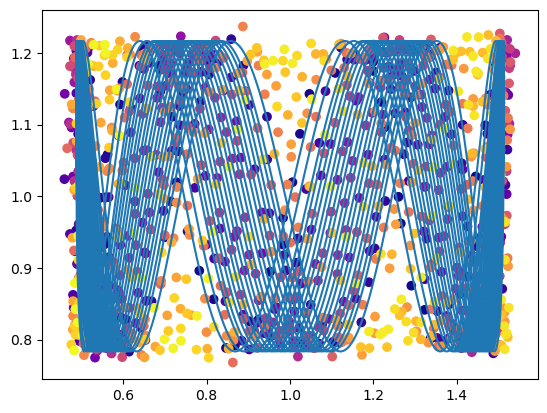

In [30]:
from scipy.optimize import differential_evolution
dt=t_data[1]-t_data[0]
L1, L2 = 1.0, 1.0
def fit(params):
    x0,y0,vx0,vy0,k1,k2=params
    n_steps=len(t_data)
    x_sim=np.zeros(n_steps)
    y_sim=np.zeros(n_steps)
    x_sim[0]=x0
    y_sim[0]=y0
    vx,vy=vx0,vy0
    for i in range(n_steps-1):
        r1 = np.abs(y_sim[i]) if np.abs(y_sim[i]) > 1e-5 else 1e-5
        r2 = np.abs(x_sim[i]) if np.abs(x_sim[i]) > 1e-5 else 1e-5
        ax = -k2 * (1.0 - L2 / r2) * x_sim[i]
        ay = -k1 * (1.0 - L1 / r1) * y_sim[i]
        vx=vx+ax*dt
        vy=vy+ay*dt
        
        x_sim[i+1]=x_sim[i]+vx*dt
        y_sim[i+1]=y_sim[i]+vy*dt
        
    total_error = np.sum((x_data - x_sim)**2) + np.sum((y_data - y_sim)**2)
    return total_error
global_bounds = [
    (x_data[0]-0.1, x_data[0]+0.1),  # x0 bound close to first data point
    (y_data[0]-0.1, y_data[0]+0.1),  # y0 bound close to first data point
    (-2.0, 2.0),                     # vx0 search window
    (-2.0, 2.0),                     # vy0 search window
    (95, 105.0),                    # k1 search window
    (1e-3, 10.0)                     # k2 search window
]
bounds = [(None, None), (None, None), (None, None), (None, None), (1e-3, None), (1e-3, None)]
result = differential_evolution(fit, bounds=global_bounds)
fitted_params = result.x
params = fitted_params
dt=0.0001
def fit_plot(params):
    x0,y0,vx0,vy0,k1,k2=params
    t=np.arange(0,t_data[-1],dt)
    x_sim=np.zeros(len(t))
    y_sim=np.zeros(len(t))
    x_sim[0]=x0
    y_sim[0]=y0
    vx,vy=vx0,vy0
    for i in range(len(t)-1):
        r1 = np.abs(y_sim[i]) if np.abs(y_sim[i]) > 1e-5 else 1e-5
        r2 = np.abs(x_sim[i]) if np.abs(x_sim[i]) > 1e-5 else 1e-5
        ax = -k2 * (1.0 - L2 / r2) * x_sim[i]
        ay = -k1 * (1.0 - L1 / r1) * y_sim[i]
        vx=vx+ax*dt
        vy=vy+ay*dt
        x_sim[i+1]=x_sim[i]+vx*dt
        y_sim[i+1]=y_sim[i]+vy*dt
        
    return x_sim,y_sim
x,y=fit_plot(params)
plt.scatter(x_data,y_data,c=t_data,cmap='plasma')
plt.plot(x,y)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# 1. USER CONFIGURATION (TRUE PHYSICAL CONSTANTS & INITIAL CONDITIONS)
# =====================================================================
G_CONST = 1.0         # Normalized Gravitational Constant
M1_TRUE = 1.2         # Mass of Planet 1
M2_TRUE = 0.8         # Mass of Planet 2

# Initial states: [x, y, vx, vy] for each planet
# Set up to orbit around their shared barycenter
P1_INIT = [-0.4, 0.0, 0.0, -0.6]  # Planet 1 (Massive)
P2_INIT = [ 0.6, 0.0, 0.0,  0.9]  # Planet 2 (Lighter)

T_MAX, DT = 6.0, 0.3
t_data = np.arange(0, T_MAX, DT)

# Combine into a single initial state vector for solve_ivp
# state = [x1, y1, vx1, vy1, x2, y2, vx2, vy2]
initial_state = P1_INIT + P2_INIT

# =====================================================================
# 2. MUTUAL GRAVITATIONAL ACCELERATION EQUATIONS
# =====================================================================
def gravitational_system_ode(t, state):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2 = state
    
    # Distance vector components
    dx = x2 - x1
    dy = y2 - y1
    r = np.sqrt(dx**2 + dy**2)
    r = np.maximum(r, 1e-3) # Prevent division by zero singularities
    
    # Accelerations derived from mutual gravitational pulling forces
    ax1 =  G_CONST * M2_TRUE * dx / r**3
    ay1 =  G_CONST * M2_TRUE * dy / r**3
    ax2 = -G_CONST * M1_TRUE * dx / r**3
    ay2 = -G_CONST * M1_TRUE * dy / r**3
    
    return [vx1, vy1, ax1, ay1, vx2, vy2, ax2, ay2]

# =====================================================================
# 3. GENERATE TARGET EXPERIMENTAL DATA MATRIX
# =====================================================================
# Integrate using a high-precision, adaptive solver
sol = solve_ivp(gravitational_system_ode, [0, T_MAX], initial_state, t_eval=t_data, rtol=1e-9)

# Extract and add measurement noise to position arrays (Simulating telemetry errors)
np.random.seed(42)
noise_level = 0.01

x_data1 = sol.y[0, :] + np.random.normal(0, noise_level, len(t_data))
y_data1 = sol.y[1, :] + np.random.normal(0, noise_level, len(t_data))
x_data2 = sol.y[4, :] + np.random.normal(0, noise_level, len(t_data))
y_data2 = sol.y[5, :] + np.random.normal(0, noise_level, len(t_data))

# =====================================================================
# 4. VISUALIZE THE TARGET TELEMETRY DATA
# =====================================================================
plt.figure(figsize=(9, 7))

# Plot Planet 1's trajectory
sc1 = plt.scatter(x_data1, y_data1, c=t_data, cmap='plasma', marker='o', alpha=0.7, label='Planet 1 (Telemetry)')
# Plot Planet 2's trajectory
sc2 = plt.scatter(x_data2, y_data2, c=t_data, cmap='plasma', marker='^', alpha=0.7, label='Planet 2 (Telemetry)')

# Add decorations
cbar = plt.colorbar(sc1)
cbar.set_label('Time Vector (t_data)', rotation=270, labelpad=15)
plt.title('2-Body Gravitational Coupling Orbit Data')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.axis('equal')
plt.show()


In [ ]:
G_CONST = 1.0
dt=t_data[1]-t_data[0]
def fit_2(params):
    x1,y1,x2,y2,vx1,vy1,vx2,vy2,M1,M2=params
    n_steps=len(t_data)
    x_sim1=np.zeros(n_steps)
    y_sim1=np.zeros(n_steps)
    x_sim2=np.zeros(n_steps)
    y_sim2=np.zeros(n_steps)
    x_sim1[0],y_sim1[0]=x1,y1
    x_sim2[0],y_sim2[0]=x2,y2
    for i in range(n_steps-1):
        R=np.sqrt((x_sim1[i]-x_sim2[i])**2+(y_sim1[i]-y_sim2[i])**2) if np.abs(np.sqrt((x_sim1[i]-x_sim2[i])**2+(y_sim1[i]-y_sim2[i])**2)) > 1e-5 else 1e-5
        dx=x_sim2[i]-x_sim1[i]
        dy=y_sim2[i]-y_sim1[i]
        ax1 =  G_CONST * M2 * dx / R**3
        ay1 =  G_CONST * M2 * dy / R**3
        ax2 = -G_CONST * M1 * dx / R**3
        ay2 = -G_CONST * M1 * dy / R**3
        vx1=vx1+ax1*dt
        vy1=vy1+ay1*dt
        vx2=vx2+ax2*dt
        vy2=vy2+ay2*dt
        x_sim1[i+1]=x_sim1[i]+vx1*dt
        y_sim1[i+1]=y_sim1[i]+vy1*dt
        x_sim2[i+1]=x_sim2[i]+vx2*dt
        y_sim2[i+1]=y_sim2[i]+vy2*dt
    error=total_error = np.sum((x_data1 - x_sim1)**2) + np.sum((y_data1 - y_sim1)**2)+np.sum((x_data2 - x_sim2)**2)+np.sum((y_data2 - y_sim2)**2)
    return error
global_bounds = [
    # --- PLANET 1 & 2 POSITIONS ---
    (x1_data[0] - 0.05, x1_data[0] + 0.05),  # x1: Search tightly around first tracking frame
    (y1_data[0] - 0.05, y1_data[0] + 0.05),  # y1: Search tightly around first tracking frame
    (x2_data[0] - 0.05, x2_data[0] + 0.05),  # x2: Search tightly around first tracking frame
    (y2_data[0] - 0.05, y2_data[0] + 0.05),  # y2: Search tightly around first tracking frame
    
    # --- PLANET 1 & 2 VELOCITIES ---
    (-3.0, 3.0),                             # vx1: Broad orbital velocity window
    (-3.0, 3.0),                             # vy1: Broad orbital velocity window
    (-3.0, 3.0),                             # vx2: Broad orbital velocity window
    (-3.0, 3.0),                             # vy2: Broad orbital velocity window
    
    # --- SYSTEM CONSTANTS ---
    (1e-2, 5.0),                             # M1: Enforces positive mass limits
    (1e-2, 5.0)                              # M2: Enforces positive mass limits
]
result = differential_evolution(
    fit_2, 
    bounds=global_bounds,
    popsize=5,          # Reduces the population size from 150 down to 50 active vectors
    maxiter=40,         # Caps the generation search cycles
    tol=0.01,           # Stops early once the paths align close enough          # CRITICAL: Distributes the load across ALL your CPU cores in parallel
)
fitted_params = result.x
params = fitted_params

dt=0.0001
def fit_plot(params):
    x1,y1,x2,y2,vx1,vy1,vx2,vy2,M1,M2=params
    t=np.arange(0,t_data[-1],dt)
    n_steps=len(t)
    x_sim1=np.zeros(n_steps)
    y_sim1=np.zeros(n_steps)
    x_sim2=np.zeros(n_steps)
    y_sim2=np.zeros(n_steps)
    x_sim1[0],y_sim1[0]=x1,y1
    x_sim2[0],y_sim2[0]=x2,y2
    for i in range(len(t)-1):
        R=np.sqrt((x_sim1[i]-x_sim2[i])**2+(y_sim1[i]-y_sim2[i])**2) if np.abs(np.sqrt((x_sim1[i]-x_sim2[i])**2+(y_sim1[i]-y_sim2[i])**2)) > 1e-5 else 1e-5
        dx=x_sim2[i]-x_sim1[i]
        dy=y_sim2[i]-y_sim1[i]
        ax1 =  G_CONST * M2 * dx / R**3
        ay1 =  G_CONST * M2 * dy / R**3
        ax2 = -G_CONST * M1 * dx / R**3
        ay2 = -G_CONST * M1 * dy / R**3
        vx1=vx1+ax1*dt
        vy1=vy1+ay1*dt
        vx2=vx2+ax2*dt
        vy2=vy2+ay2*dt
        x_sim1[i+1]=x_sim1[i]+vx1*dt
        y_sim1[i+1]=y_sim1[i]+vy1*dt
        x_sim2[i+1]=x_sim2[i]+vx2*dt
        y_sim2[i+1]=y_sim2[i]+vy2*dt
        
    return x_sim1,y_sim1,x_sim2,y_sim2
x1,y1,x2,y2=fit_plot(params)
plt.plot(x1,y1)
plt.plot(x2,y2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k1
from scipy.optimize import differential_evolution

matrix = np.loadtxt(
    'data 1.txt',
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.'))
)


t_data1 = matrix[:-28, 0]
x_data1 = matrix[:-28, 1]
y_data1 = matrix[:-28, 2]

plt.close('all')
sc1 = plt.scatter(x_data1, y_data1, c=t_data1, cmap='plasma', s=3, label="Particle 1 Path")
matrix = np.loadtxt(
    'data 2.txt',
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.'))
)
t_data2 = matrix[:-28, 0]
x_data2 = matrix[:-28, 1]
y_data2 = matrix[:-28, 2]
sc2 = plt.scatter(x_data2, y_data2, c=t_data2, cmap='plasma', s=3, label="Particle 2 Path")
plt.ylabel('y')
plt.xlabel('x')

Lc = 2.7 * 10 ** (-3)

dt=t_data1[1]-t_data1[0]
def cheerios_fit(params):
    x_sim1_0, y_sim1_0, vx_sim1_0, vy_sim1_0,x_sim2_0, y_sim2_0, vx_sim2_0, vy_sim2_0,A,B = params
    t = np.arange(0, t_data1[-1]+dt/2, dt)
    x_sim1 = np.zeros(len(t_data1))
    y_sim1 = np.zeros(len(t_data1))
    x_sim2 = np.zeros(len(t_data1))
    y_sim2 = np.zeros(len(t_data1))
    x_sim2[0], y_sim2[0]=x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0]=x_sim1_0, y_sim1_0
    vx1=vx_sim1_0
    vy1=vy_sim1_0
    vx2=vx_sim2_0
    vy2=vy_sim2_0
    for i in range(len(t_data1) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
    error =np.sum((x_data1 - x_sim1) ** 2) + np.sum((y_data1 - y_sim1) ** 2) + np.sum(
        (x_data2 - x_sim2) ** 2) + np.sum((y_data2 - y_sim2) ** 2)
    return error

global_bounds=((x_data1[0] - 0.05, x_data1[0] + 0.05),
               (y_data1[0] - 0.05, y_data1[0] + 0.05),
               (-1,1),
               (-1,1),
               (x_data2[0] - 0.05, x_data2[0] + 0.05),
               (y_data2[0] - 0.05, y_data2[0] + 0.05),
               (-1,1),
               (-1,1),
               (0,2),
               (0,2),
               )
result = differential_evolution(
    cheerios_fit,
    bounds=global_bounds
    )
fitted_params = result.x
params = fitted_params


def cheerios_plot(params):
    x_sim1_0, y_sim1_0, vx_sim1_0, vy_sim1_0, x_sim2_0, y_sim2_0, vx_sim2_0, vy_sim2_0, A, B = params
    t = np.arange(0, t_data1[-1] + dt / 2, dt)
    x_sim1 = np.zeros(len(t))
    y_sim1 = np.zeros(len(t))
    x_sim2 = np.zeros(len(t))
    y_sim2 = np.zeros(len(t))
    x_sim2[0], y_sim2[0] = x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0] = x_sim1_0, y_sim1_0
    vx1 = vx_sim1_0
    vy1 = vy_sim1_0
    vx2 = vx_sim2_0
    vy2 = vy_sim2_0
    for i in range(len(t) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
        if r<0.01:
            end_index=i+1
            break

    return x_sim1[:end_index], y_sim1[:end_index], x_sim2[:end_index],y_sim2[:end_index]

x1,y1,x2,y2=cheerios_plot(params)
plt.plot(x1,y1)
plt.plot(x2,y2)
plt.show()